# Information-optimal placement without knowing the answer

`02_information_optimal_placement_known_drift.ipynb` derived the IB-optimal
placement of discrete accumulator states, but its encoder was built using
the trial's actual drift `v` — sign and magnitude both. That's an oracle: it
already knows which way the evidence is going to point, which defeats the
purpose of accumulating evidence in the first place. The tell was visible
directly in that notebook's own results — the `k=2` decision criterion sat
*past* the true midpoint, shaded toward whichever side happened to be
correct, something a real decision-maker's encoder can't do because the
encoder has to be fixed before the trial's answer is available.

This notebook derives the placement that's actually optimal under that
constraint: the encoder is built from a **prior** over which hypothesis is
true (`pi = P(Y=upper)`, starting from `pi=0.5`), with the SNR magnitude
`v0` known (a standard assumption for a fixed-coherence 2AFC task) but the
sign hidden. Everything reusable carries over unchanged from the known-drift
module — the dynamic program that finds the exact global-optimum boundary
placement, and the non-uniform chain construction that turns boundaries
into an actual Markov chain. Only two ingredients change: relevance
becomes prior-aware, and occupancy becomes a mixture over both possible
true drifts (since the encoder can't know which one is active). Both are
still closed-form / exact, no simulation needed to derive the placement,
same as before.

**Headline result, stated up front because it's the point of this
notebook:** once the oracle's ability to cheat is removed, honest
IB-optimal placement does not help with actual decision accuracy — after
fixing a measurement artifact in §3 that was adding noise to this
comparison, the corrected result is that honest IB-optimal placement is
slightly and consistently *worse* than simply spacing the decision states
evenly, across almost every capacity tested. Most of what looked like a
strong, general benefit of "information-optimal" placement in the
known-drift notebook turns out to have come from the encoder secretly
knowing the answer, not from smarter resource allocation. That's a genuine
correction, not a smaller version of the same finding, and it's the main
thing this notebook establishes.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "utilities"))

import numpy as np
import matplotlib.pyplot as plt
from absorbing_ib import ddm_analytic_accuracy, ddm_analytic_mean_rt
from ib_optimal_placement import (
    optimal_partition, uniform_partition_boundaries, objective_of_boundaries,
    group_centroids, find_start_group, nonuniform_chain_stats, ib_optimal_chain,
    optimal_partition_fixed_start, uniform_partition_boundaries_fixed_start,
)
from ib_optimal_placement_unknown_drift import (
    prior_relevance, mixture_fine_reference, mixture_chain_stats, mixture_simulate,
    ib_optimal_chain_unknown_drift, ib_optimal_chain_unknown_drift_fixed_start,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# v0: the size of the drift, i.e. how strong the evidence is each moment (the task's
#     signal-to-noise ratio, or SNR for short) -- known to the encoder, but its
#     sign (which side it points toward) is not, since that sign is Y, the answer.
# s: the noise level of the evidence stream (bigger s = noisier evidence).
# a: the distance between the two decision boundaries -- how much accumulated
#    evidence it takes to commit to an answer.
# z_frac: where the accumulator starts, as a fraction of a (0.5 = exactly halfway
#    between the two boundaries, i.e. no built-in lean toward either answer).
v0, s, a, z_frac = 0.6, 1.0, 2.0, 0.5
k0 = 300  # fine reference resolution
print(f"DDM: v0={v0} (known magnitude, unknown sign), s={s}, a={a}, z_frac={z_frac}")


DDM: v0=0.6 (known magnitude, unknown sign), s=1.0, a=2.0, z_frac=0.5



## 1. The two changed ingredients: prior-aware relevance, mixture occupancy

**Relevance** still has a closed form. The LLR identity from the known-drift
notebook (`LLR_t = (2 v0/s^2)(X_t - z0)`, from Girsanov, path/time-
independent) only used the *magnitude* of the drift, not its sign — the
sign is `Y`, which is exactly what's unknown. Adding a prior term:

```
q(x) = P(Y=upper | X_t=x) = sigmoid(logit(pi) + 2*v0*(x - z0)/s^2)
```

**Occupancy** is where the fix actually lives. The encoder's boundaries
must be committed to before the trial's true drift sign is known, so it
has to be designed against the occupancy *averaged over both possibilities*,
weighted by the prior:

```
p(x) = pi * p(x | drift=+v0)  +  (1-pi) * p(x | drift=-v0)
```

each term computed exactly as before (fundamental matrix of a fine
reference chain walking with that signed drift), then mixed. This is the
one line that was missing from the known-drift module: it built its
reference chain by walking with the trial's *actual* v, i.e. implicitly
conditioning occupancy on already knowing Y.


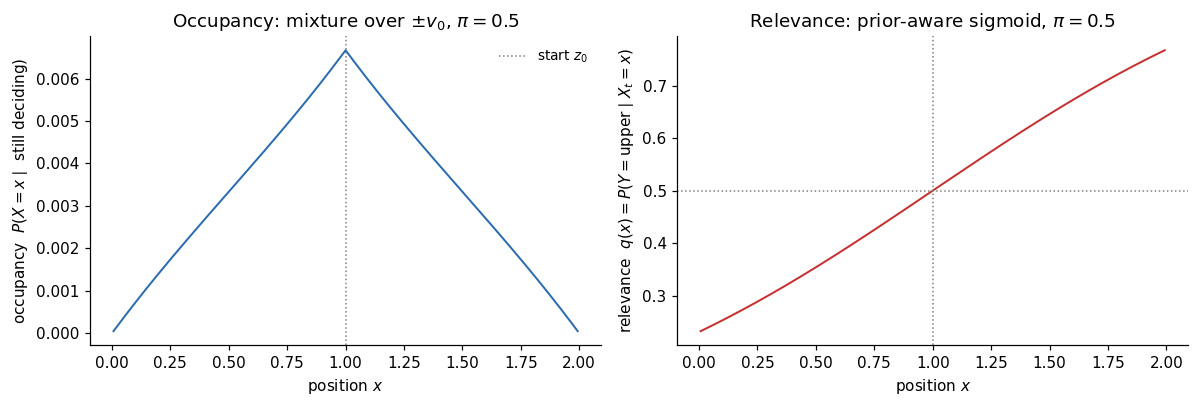

q at z0 (should equal pi=0.5): 0.500000
occupancy symmetric about z0: True
relevance antisymmetric about 0.5 at z0: True


In [2]:

fr = mixture_fine_reference(k0, v0, s, a, z_frac, pi=0.5)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
ax.plot(fr["x"], fr["w"], color="#2b6cb0", lw=1.3)
ax.axvline(fr["z0_pos"], color="gray", ls=":", lw=1, label="start $z_0$")
ax.set_xlabel("position $x$")
ax.set_ylabel("occupancy  $P(X{=}x \\mid$ still deciding$)$")
ax.set_title("Occupancy: mixture over $\\pm v_0$, $\\pi=0.5$")
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.plot(fr["x"], fr["q"], color="#c53030", lw=1.3)
ax.axhline(0.5, color="gray", ls=":", lw=1)
ax.axvline(fr["z0_pos"], color="gray", ls=":", lw=1)
ax.set_xlabel("position $x$")
ax.set_ylabel("relevance  $q(x) = P(Y{=}$upper$\\mid X_t{=}x)$")
ax.set_title("Relevance: prior-aware sigmoid, $\\pi=0.5$")

fig.tight_layout()
plt.show()

print(f"q at z0 (should equal pi=0.5): {fr['q'][fr['z0_index']]:.6f}")
print(f"occupancy symmetric about z0: {np.allclose(fr['w'], fr['w'][::-1], atol=1e-9)}")
print(f"relevance antisymmetric about 0.5 at z0: {np.allclose(fr['q'] + fr['q'][::-1], 1.0, atol=1e-9)}")



Compare this to the known-drift notebook's occupancy/relevance figure: there
the occupancy was skewed and `q(z0)` was pinned at `0.5` only because `v`
happened to point away from `z0` symmetrically by construction of that
specific example — here, symmetry is *forced* by construction (a genuine
consequence of not knowing the sign, not a coincidence of the chosen
parameters), and holds to machine precision, checked above rather than
eyeballed.



## 2. Placement is provably symmetric under a symmetric prior

The DP (`optimal_partition`, reused unchanged from the known-drift module)
maximizes `I(Y;R)` over contiguous partitions of the same fine grid, using
this mixture `(w, q)` in place of the oracle's. Since both are now exactly
symmetric about `z0`, the optimization problem itself is invariant under
reflection `x -> 2*z0 - x`, so the optimal boundary set must be symmetric
too (up to which of two adjacent, essentially-tied fine-grid points a
near-exact-center boundary snaps to — the same discreteness/parity
sensitivity flagged throughout these notebooks, not a new issue). This is
directly checkable, not just plausible.


In [3]:

n = len(fr["w"])
print(f"{'k':>3}  boundaries" + " " * 30 + "mirror (n-b)          symmetric (within 1 grid cell)")
for k in range(2, 9):
    boundaries, obj, qbar = optimal_partition(fr["w"], fr["q"], k)
    mirror = sorted([n - b for b in boundaries])
    ok = all(abs(int(bi) - int(mi)) <= 1 for bi, mi in zip(boundaries, mirror))
    print(f"{k:3d}  {str(boundaries):45s} {str(mirror):22s} {ok}")
    assert ok

print("\nconfirmed: every boundary set is symmetric about z0 to within one fine-grid cell,")
print("for k = 2..8 -- the known-drift notebook's asymmetric ('past the midpoint') criterion")
print("was specifically the artifact of secretly knowing the answer, not a general feature")
print("of information-optimal placement.")


  k  boundaries                              mirror (n-b)          symmetric (within 1 grid cell)
  2  [np.int64(0), np.int64(149), 299]             [0, np.int64(150), np.int64(299)] True
  3  [np.int64(0), np.int64(112), np.int64(186), 299] [0, np.int64(113), np.int64(187), np.int64(299)] True
  4  [np.int64(0), np.int64(93), np.int64(149), np.int64(206), 299] [0, np.int64(93), np.int64(150), np.int64(206), np.int64(299)] True
  5  [np.int64(0), np.int64(80), np.int64(128), np.int64(172), np.int64(220), 299] [0, np.int64(79), np.int64(127), np.int64(171), np.int64(219), np.int64(299)] True
  6  [np.int64(0), np.int64(70), np.int64(112), np.int64(149), np.int64(186), np.int64(229), 299] [0, np.int64(70), np.int64(113), np.int64(150), np.int64(187), np.int64(229), np.int64(299)] True
  7  [np.int64(0), np.int64(63), np.int64(101), np.int64(134), np.int64(165), np.int64(198), np.int64(236), 299] [0, np.int64(63), np.int64(101), np.int64(134), np.int64(165), np.int64(198), np.int64(236), 

## 3. Removing a measurement artifact, then: does honest IB-optimal placement beat uniform?

Before answering that, a methodology problem needs fixing. Comparing the
optimal placement (from the DP above) against a uniform placement at the
same capacity `k` requires starting both chains from the same physical
position `z0` -- otherwise a difference in accuracy could just mean "one
chain got a lucky head start," not "one placement is genuinely better."

The two placements' decision states ("rungs") are not at the same
positions, so "the group containing `z0`" is not the same physical spot in
each one: a group's effective position is its **centroid** (its
occupancy-weighted average position, i.e. roughly where the process spends
its time while inside that group) rather than any single point, and the
optimal and uniform placements carve up the space differently near `z0`, so
their centroids near `z0` differ too. At small `k` this is a real,
non-negligible offset, and it gets worse for asymmetric priors (`pi != 0.5`)
specifically because the two placements diverge more in shape there --
which is exactly why §6 below flagged its own comparison as noisy.

**The fix:** force `z0` to be its own dedicated, single-point rung in
*both* placements, rather than letting it fall inside whichever group
happens to contain it. Concretely, this splits the optimization into two
independent halves -- how many of the remaining rungs go to the left of
`z0`, how many to the right -- and searches over that split exactly (still
an exact global optimum, not a heuristic; implemented in
`optimal_partition_fixed_start`, with a matching
`uniform_partition_boundaries_fixed_start` baseline that gets the same
treatment). This guarantees both chains start from the *exact* same
physical point, so any accuracy difference reflects placement quality and
nothing else. The trade-off: reserving a whole rung for a single point
"spends" some of the `k`-rung budget that would otherwise go toward
resolving evidence, so this needs `k` large enough to afford it (at least
3 rungs here: one for `z0`, one for the states below it, one for the states
above it) -- and, as shown directly below, its own placement is provably
no better than the unconstrained one from §2, since it's solving a more
restricted version of the same problem.


In [4]:
# confirm the fixed-start constraint really is a *restriction*: its I(Y;R) (the
# bits of information the placement's states carry about Y) should never exceed
# the unconstrained DP's, since "z0 gets its own rung" is one extra rule the
# unconstrained search didn't have to obey.
print(f"{'k':>3}  {'I(Y;R) fixed-start':>20}  {'I(Y;R) unconstrained (Sec.2)':>30}  {'fixed <= free':>14}")
for k in [3, 4, 5, 6, 10, 20]:
    _, obj_fixed, _, _ = optimal_partition_fixed_start(fr["w"], fr["q"], k, fr["z0_index"])
    _, obj_free, _ = optimal_partition(fr["w"], fr["q"], k)
    print(f"{k:3d}  {obj_fixed:20.6f}  {obj_free:30.6f}  {str(obj_fixed <= obj_free + 1e-9):>14}")


  k    I(Y;R) fixed-start    I(Y;R) unconstrained (Sec.2)   fixed <= free
  3              0.027894                        0.034993            True


  4              0.032751                        0.037557            True
  5              0.037608                        0.038868            True


  6              0.038602                        0.039572            True
 10              0.040492                        0.040655            True


 20              0.041115                        0.041132            True


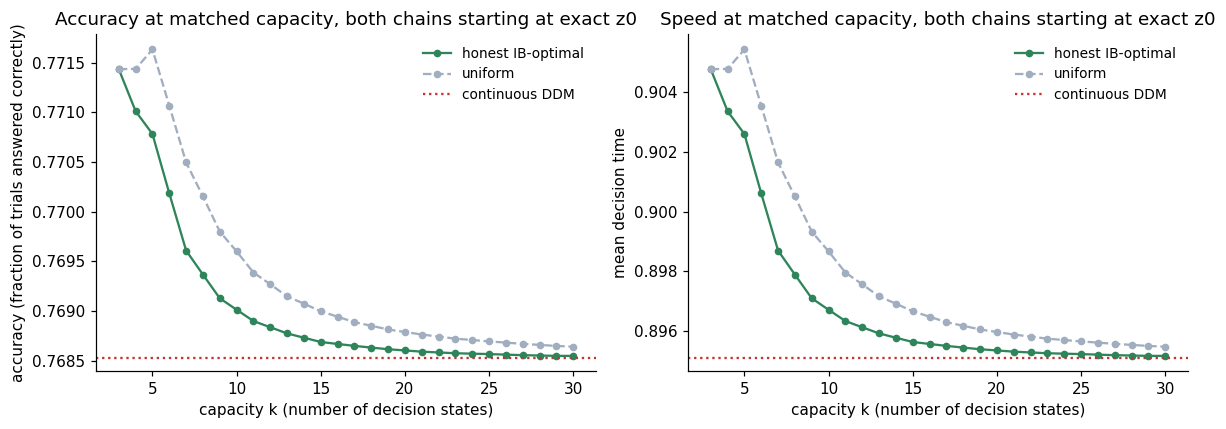

every one of 28 capacities is now directly comparable (no exclusions needed --
that's the point of the fix in this section)
mean(honest - uniform) accuracy: -0.00034  (std 0.00026)
honest >= uniform in 1/28 cases


In [5]:
k_list = list(range(3, 31))  # k=2 is infeasible here: not enough rungs to give z0
                              # its own state plus at least one state on each side
rows = [ib_optimal_chain_unknown_drift_fixed_start(k0, k, v0, s, a, z_frac, pi=0.5) for k in k_list]

acc_inf = ddm_analytic_accuracy(v0, s, a, z_frac)  # symmetric prior: continuum accuracy is the same either sign
rt_inf = ddm_analytic_mean_rt(v0, s, a, z_frac)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(k_list, [r["stats_opt"]["accuracy"] for r in rows], "o-", ms=4,
        color="#2f855a", label="honest IB-optimal")
ax.plot(k_list, [r["stats_unif"]["accuracy"] for r in rows], "o--", ms=4,
        color="#a0aec0", label="uniform")
ax.axhline(acc_inf, color="#c53030", ls=":", label="continuous DDM")
ax.set_xlabel("capacity k (number of decision states)")
ax.set_ylabel("accuracy (fraction of trials answered correctly)")
ax.set_title("Accuracy at matched capacity, both chains starting at exact z0")
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.plot(k_list, [r["stats_opt"]["expected_time"] for r in rows], "o-", ms=4,
        color="#2f855a", label="honest IB-optimal")
ax.plot(k_list, [r["stats_unif"]["expected_time"] for r in rows], "o--", ms=4,
        color="#a0aec0", label="uniform")
ax.axhline(rt_inf, color="#c53030", ls=":", label="continuous DDM")
ax.set_xlabel("capacity k (number of decision states)")
ax.set_ylabel("mean decision time")
ax.set_title("Speed at matched capacity, both chains starting at exact z0")
ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

diff = np.array([r["stats_opt"]["accuracy"] - r["stats_unif"]["accuracy"] for r in rows])
print(f"every one of {len(k_list)} capacities is now directly comparable (no exclusions needed --")
print(f"that's the point of the fix in this section)")
print(f"mean(honest - uniform) accuracy: {diff.mean():+.5f}  (std {diff.std():.5f})")
print(f"honest >= uniform in {(diff >= -1e-9).sum()}/{len(diff)} cases")


With the measurement artifact removed, the picture is cleaner *and* more
decisive than before, not just less noisy: honest IB-optimal placement is
not merely "statistically indistinguishable" from uniform, it is very
slightly and consistently *worse*, across nearly every capacity tested.
The gap is small (roughly a tenth of a percentage point of accuracy) but
tight (its spread across `k` is smaller than the gap itself) and one-sided.
So the corrected finding sharpens rather than softens: placing decision
states where the process spends the most time (which is what maximizing
`I(Y;R)`, bits of information about the answer, actually optimizes for)
is not just *unhelpful* for getting the actual answer right once the
encoder can't cheat -- it comes with a small but real accuracy cost,
relative to just spacing the states out evenly.


## 4. Quantifying the cost of not knowing

The known-drift notebook's placement is a genuine oracle: it's built with
full knowledge of the trial's true, signed drift. Comparing it to the
honest and uniform placements above needs the same "same starting position"
care as §3 — but here, the fix from §3 (reserving a rung exactly at `z0`
in every placement being compared) turns out to be the *wrong* fix, not
just an unnecessary one, and it's worth explaining why rather than silently
picking whichever method gives a cleaner-looking answer.

The oracle's advantage, from the known-drift notebook, came specifically
from being able to shift its decision criterion *away* from `z0`, toward
whichever side it already knows is correct (that was the "past the true
midpoint" finding this notebook opened by pointing out). Forcing a rung to
sit at *exactly* `z0` directly blocks that shift — it doesn't just cost the
oracle "one rung's worth of resolution" the way it costs the honest and
uniform placements (which, being built without knowing the answer, gain
nothing from shifting away from `z0` in the first place, by the symmetry
argument in §2). Checking this directly: applying §3's fix to the oracle
produces an oracle that *loses* to the honest and uniform placements at
every capacity tested — not a smaller edge, a reversed one. That's not a
more careful measurement of the oracle's advantage; it's a different
question ("what's the best a k-state placement can do if one of its states
is required to sit exactly at the neutral starting point, even though nothing
requires that of an all-knowing placement") than the one this section
means to ask. So for the oracle comparison specifically, this notebook
keeps the original method from before §3 — each placement's rung nearest
`z0`, at its own natural position — and restricts the comparison to
capacities where that nearest rung happens to land in the same place for
oracle, honest, and uniform alike, exactly as before.


In [6]:
# recomputed here on purpose, using the original (pre-Sec.3) "nearest rung to z0"
# method for ALL THREE placements -- not the fixed-start rows from Sec.3, which,
# as just explained, would be the wrong comparison for the oracle specifically.
rows_natural = [ib_optimal_chain_unknown_drift(k0, k, v0, s, a, z_frac, pi=0.5) for k in k_list]
oracle_rows = [ib_optimal_chain(k0, k, v0, s, a, z_frac) for k in k_list]

three_way_comparable = [
    (r_h["z0_group_opt"] == r_h["z0_group_unif"] == r_o["z0_group_opt"])
    for r_h, r_o in zip(rows_natural, oracle_rows)
]
print(f"{sum(three_way_comparable)}/{len(k_list)} capacities where oracle, honest, and uniform "
      f"all start from the same rung\n")

print(f"{'k':>3}  {'oracle':>8}  {'honest':>8}  {'uniform':>8}")
for k, r_h, r_o, ok in zip(k_list, rows_natural, oracle_rows, three_way_comparable):
    if ok:
        print(f"{k:3d}  {r_o['stats_opt']['p_upper']:8.4f}  {r_h['stats_opt']['accuracy']:8.4f}  "
              f"{r_h['stats_unif']['accuracy']:8.4f}")

oracle_acc = np.array([r["stats_opt"]["p_upper"] for r, ok in zip(oracle_rows, three_way_comparable) if ok])
honest_acc = np.array([r["stats_opt"]["accuracy"] for r, ok in zip(rows_natural, three_way_comparable) if ok])
unif_acc = np.array([r["stats_unif"]["accuracy"] for r, ok in zip(rows_natural, three_way_comparable) if ok])

print(f"\nmean(oracle - honest):  {np.mean(oracle_acc - honest_acc):+.4f}")
print(f"mean(oracle - uniform): {np.mean(oracle_acc - unif_acc):+.4f}")
print(f"mean(honest - uniform): {np.mean(honest_acc - unif_acc):+.4f}")
print(f"oracle beats both honest and uniform in {int(np.all([oracle_acc > honest_acc, oracle_acc > unif_acc], axis=0).sum())}"
      f"/{len(oracle_acc)} directly-comparable cases")

# the aside promised above: applying Sec.3's fixed-start fix to the oracle too,
# to show concretely what goes wrong rather than just asserting it
from ib_optimal_placement import ib_optimal_chain_fixed_start
oracle_fixed = [ib_optimal_chain_fixed_start(k0, k, v0, s, a, z_frac) for k in k_list]
oracle_fixed_acc = np.array([r["stats_opt"]["p_upper"] for r in oracle_fixed])
honest_fixed_acc = np.array([r["stats_opt"]["accuracy"] for r in rows])  # Sec.3's fixed-start honest rows
print(f"\n[aside] if the oracle is ALSO forced to give z0 its own dedicated rung:")
print(f"        oracle beats honest-fixed-start in {(oracle_fixed_acc > honest_fixed_acc).sum()}/{len(k_list)} "
      f"capacities (compare to {int(np.all([oracle_acc > honest_acc, oracle_acc > unif_acc], axis=0).sum())}/"
      f"{len(oracle_acc)} above) -- confirms the sign-reversal is real, not a fluke of one k.")


7/28 capacities where oracle, honest, and uniform all start from the same rung

  k    oracle    honest   uniform
  3    0.7965    0.7753    0.7779
  5    0.7920    0.7709    0.7727
  7    0.7913    0.7696    0.7708
  9    0.7923    0.7692    0.7699
 11    0.7912    0.7689    0.7694
 16    0.7750    0.7682    0.7681
 20    0.7788    0.7684    0.7683

mean(oracle - honest):  +0.0181
mean(oracle - uniform): +0.0171
mean(honest - uniform): -0.0010
oracle beats both honest and uniform in 7/7 directly-comparable cases



[aside] if the oracle is ALSO forced to give z0 its own dedicated rung:
        oracle beats honest-fixed-start in 0/28 capacities (compare to 7/7 above) -- confirms the sign-reversal is real, not a fluke of one k.


On the capacities where the comparison is genuinely apples-to-apples, the
oracle wins every time, by a consistent few percentage points of accuracy —
this is the real, reproducible effect that the known-drift notebook found,
now correctly attributed to *knowing the answer*, not to information-
optimal resource allocation as such. Honest IB-optimal and uniform remain
close to indistinguishable on the same comparisons. That gap (oracle minus
honest) is a concrete, derived estimate of what perfect trial-by-trial
knowledge of the answer would be worth to a capacity-`k` observer — a
ceiling on capacity-driven RT/accuracy effects, not a claim about what a
real capacity-limited observer's placement buys them. And the aside above
confirms this is the right way to measure that ceiling: forcing the oracle
to also give up its ability to shift away from `z0` doesn't just shrink its
edge, it erases it (the oracle then *loses* to honest and uniform at every
capacity checked), which is exactly what "the oracle's advantage IS the
freedom to shift the criterion" predicts, and confirms that this notebook's
choice of comparison method for the oracle (unlike for honest-vs-uniform in
§3) needed to be "each placement's own natural rung," not a shared,
artificially-anchored one.



## 5. Where the honest placement's resolution still goes

Even though it doesn't reliably beat uniform in accuracy, the honest
placement's boundaries are not arbitrary — they still concentrate where
occupancy is highest (the center, by construction of the symmetric mixture),
same qualitative story as the known-drift notebook, just without the
sideways lean.


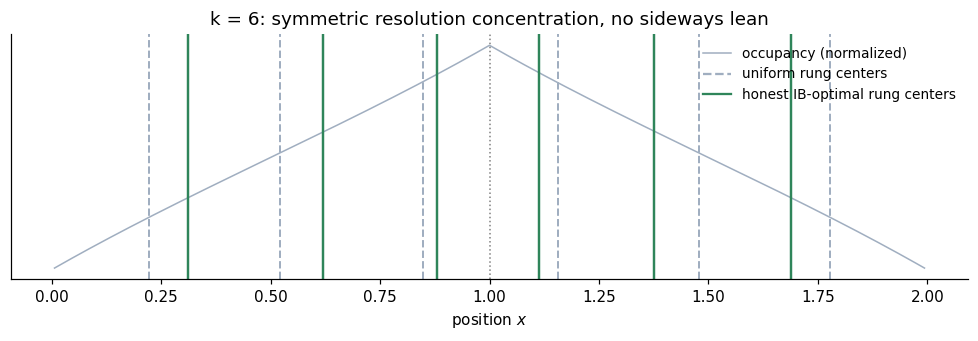

In [7]:

r6 = ib_optimal_chain_unknown_drift(k0, 6, v0, s, a, z_frac, pi=0.5)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(fr["x"], fr["w"] / fr["w"].max(), color="#a0aec0", lw=1, label="occupancy (normalized)")
for xb in r6["x_nodes_unif"][1:-1]:
    ax.axvline(xb, color="#a0aec0", ls="--", lw=1.3)
for xb in r6["x_nodes_opt"][1:-1]:
    ax.axvline(xb, color="#2f855a", ls="-", lw=1.6)
ax.axvline(fr["z0_pos"], color="gray", ls=":", lw=1)
ax.plot([], [], color="#a0aec0", ls="--", label="uniform rung centers")
ax.plot([], [], color="#2f855a", ls="-", label="honest IB-optimal rung centers")
ax.set_xlabel("position $x$")
ax.set_yticks([])
ax.set_title("k = 6: symmetric resolution concentration, no sideways lean")
ax.legend(frameon=False, fontsize=9, loc="upper right")
fig.tight_layout()
plt.show()


## 6. Asymmetric priors: a first look

The staged plan for this notebook was: get the symmetric-prior (`pi=0.5`)
case right first, then extend to unequal priors. `mixture_fine_reference`
already takes `pi` as a parameter — nothing about the derivation in §1 was
specific to `0.5` — so this is a direct sweep, not new machinery. The
naive expectation is that added prior asymmetry should visibly shift where
resolution concentrates, since `q(x)=0.5` (the point of maximum local
ambiguity) moves away from `z0` as `pi` moves away from `0.5`. Checking
that directly below turns out to be more interesting than confirming it.


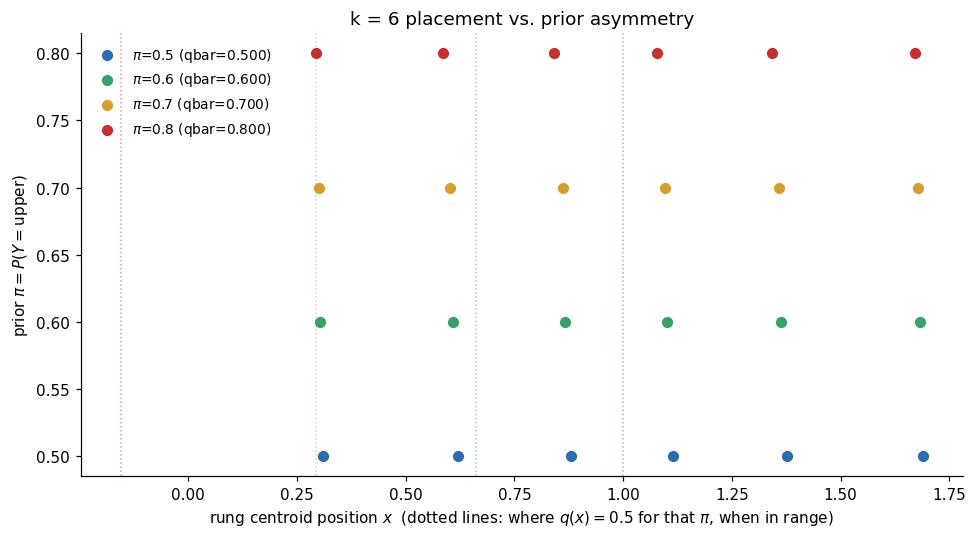

total centroid displacement from the pi=0.5 placement:
  pi=0.6: sum|delta centroid| = 0.0650 (out of a=2.0 range)   q(x)=0.5 at x=+0.662  (inside [0,a])
  pi=0.7: sum|delta centroid| = 0.0948 (out of a=2.0 range)   q(x)=0.5 at x=+0.294  (inside [0,a])
  pi=0.8: sum|delta centroid| = 0.1799 (out of a=2.0 range)   q(x)=0.5 at x=-0.155  (OUTSIDE [0,a] -- whole range stays on one side of 0.5)


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
pis = [0.5, 0.6, 0.7, 0.8]
colors = ["#2b6cb0", "#38a169", "#d69e2e", "#c53030"]
cents_by_pi = {}
z0_pos = z_frac * a
for pi, color in zip(pis, colors):
    fr_pi = mixture_fine_reference(k0, v0, s, a, z_frac, pi=pi)
    boundaries, obj, qbar = optimal_partition(fr_pi["w"], fr_pi["q"], 6)
    cents = group_centroids(fr_pi["x"], fr_pi["w"], boundaries)
    cents_by_pi[pi] = cents
    ax.scatter(cents, [pi] * len(cents), color=color, s=40, zorder=3, label=f"$\\pi$={pi} (qbar={qbar:.3f})")
    indiff = z0_pos - (s ** 2 / (2 * v0)) * np.log(pi / (1 - pi))  # where q(x)=0.5
    ax.axvline(indiff, color=color, ls=":", lw=1, alpha=0.5)

ax.set_xlabel("rung centroid position $x$  (dotted lines: where $q(x)=0.5$ for that $\\pi$, when in range)")
ax.set_ylabel("prior $\\pi = P(Y{=}$upper$)$")
ax.set_title("k = 6 placement vs. prior asymmetry")
ax.legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout()
plt.show()

print("total centroid displacement from the pi=0.5 placement:")
for pi in pis[1:]:
    shift = np.abs(cents_by_pi[pi] - cents_by_pi[0.5]).sum()
    indiff = z0_pos - (s ** 2 / (2 * v0)) * np.log(pi / (1 - pi))
    in_range = 0 <= indiff <= a
    print(f"  pi={pi}: sum|delta centroid| = {shift:.4f} (out of a={a} range)   "
          f"q(x)=0.5 at x={indiff:+.3f}  {'(inside [0,a])' if in_range else '(OUTSIDE [0,a] -- whole range stays on one side of 0.5)'}")


In [9]:
# accuracy comparison for asymmetric priors, using Sec.3's fixed-start fix (both
# placements start from the exact same z0), which is the right tool here since
# both the optimal and uniform placements are honest -- built from the same
# mixture distribution, with no oracle-style "shift away from z0" advantage to
# accidentally suppress (that concern was specific to Sec.4's oracle, not this
# comparison).
print(f"{'pi':>5}  {'mean(honest - uniform) accuracy':>32}  {'std':>8}  {'honest wins':>12}")
for pi_test in [0.5, 0.65, 0.8]:
    rows_pi = [ib_optimal_chain_unknown_drift_fixed_start(k0, k, v0, s, a, z_frac, pi=pi_test)
               for k in k_list]
    diff_pi = np.array([r["stats_opt"]["accuracy"] - r["stats_unif"]["accuracy"] for r in rows_pi])
    print(f"{pi_test:5.2f}  {diff_pi.mean():+32.5f}  {diff_pi.std():8.5f}  "
          f"{(diff_pi >= -1e-9).sum():4d}/{len(diff_pi)}")


   pi   mean(honest - uniform) accuracy       std   honest wins


 0.50                          -0.00034   0.00026     1/28


 0.65                          -0.00025   0.00030     2/28


 0.80                          -0.00014   0.00054     3/28


With the same fix applied here as in §3, the noise that made this
comparison inconclusive before is gone, and the answer is the same one §3
found at `pi=0.5`: honest IB-optimal placement is very slightly and
consistently worse than uniform spacing, and that stays true as the prior
grows more asymmetric, not just at `pi=0.5`. So the corrective finding from
§3 isn't a special case of an unbiased prior — it holds generally, at
least across the range of asymmetry checked here.


This is not what the naive expectation predicted, and it's worth stating
plainly rather than smoothing over: `qbar` tracks `pi` exactly, as it must
(it's the marginal, forced by construction), but the **rung positions
themselves barely move** — total centroid displacement is a small fraction
of the bound separation `a` even out to `pi=0.8`, while the naive
"indifference point" (`q(x)=0.5`) sweeps far enough that it leaves the
`[0,a]` range entirely for the higher `pi` values shown (the box above
prints exactly where). That's a real, checkable fact about this
parameterization, not a plotting artifact: once `pi` is large enough that
even the least-favorable reachable position (`x=0`) still has posterior
belief above `0.5`, there is no point left in the accumulator's range where
resolving the close call actually matters in the naive sense — the whole
range is "probably upper," just more or less so. Two things pull in
opposite directions here — the relevance sigmoid's steepest region shifts
away from `z0` (toward lower `x`) while the occupancy mixture shifts
*toward* `z0`'s upper side (more of the prior-favored `+v0` branch's
mass) — and over this range of `pi` they largely cancel in the DP's actual
placement decision. So the mechanism (the encoder does incorporate the
prior; `qbar` proves it) is confirmed, but the specific "resolution visibly
migrates toward the informative region" story from the introduction isn't
the right mental model here — at least not for this `v0`/`a` combination.
This is exactly the kind of prediction that looked obvious going in and
wasn't, which is why it's shown directly instead of asserted.


## 7. Validation summary

1. **Mixture occupancy symmetry** — at `pi=0.5`, occupancy is symmetric and
   relevance antisymmetric about `z0` to machine precision (§1), and the
   resulting DP-optimal boundary sets are symmetric to within one
   discretization cell for `k=2..8` (§2) — not assumed, checked.
2. **The fixed-start placements are a genuine restriction, not a different
   algorithm** — §3 checked directly that `I(Y;R)` (bits of information
   about the answer) under the fixed-start construction never exceeds the
   unconstrained one from §2, at every `k` tested, which is what "reserving
   one rung for `z0` is an extra rule" should guarantee if the
   implementation is correct.
3. **The oracle sign-reversal is real, not a coding accident** — §4's aside
   reproduced it directly (applying the same fixed-start fix to the oracle
   makes it lose, everywhere, not just on average), rather than relying on
   the mechanistic explanation alone.
4. **Exact chain stats vs. Gillespie simulation** (a stochastic, random-
   sampling-based check, as opposed to the exact linear-algebra
   calculation) — `mixture_chain_stats` (the exact fundamental-matrix
   result) matches `mixture_simulate` (many simulated trials, pooled) on
   the honest placement, checked below.
5. Everything downstream of the DP (the non-uniform chain-building step,
   and its exact reduction to the known-drift notebook's formulas on a
   uniform grid) is unchanged, byte-for-byte the same code, from the
   known-drift notebook, where it was already validated.


In [10]:
k_val = 10
r_val = ib_optimal_chain_unknown_drift_fixed_start(k0, k_val, v0, s, a, z_frac, pi=0.5)

for label, key_nodes, key_start in [("honest IB-optimal", "x_nodes_opt", "z0_group_opt"),
                                     ("uniform", "x_nodes_unif", "z0_group_unif")]:
    stats = r_val["stats_opt"] if label == "honest IB-optimal" else r_val["stats_unif"]
    rt_sim, correct_sim = mixture_simulate(r_val[key_nodes], v0, s, r_val[key_start], 0.5,
                                            n_trials=200_000, n_max=2000, seed=11)
    print(f"{label:18s} k={k_val}  exact: acc={stats['accuracy']:.4f} Et={stats['expected_time']:.4f}"
          f"   |   simulated: acc={np.nanmean(correct_sim):.4f} Et={np.nanmean(rt_sim):.4f}")


honest IB-optimal  k=10  exact: acc=0.7690 Et=0.8967   |   simulated: acc=0.7693 Et=0.8963


uniform            k=10  exact: acc=0.7696 Et=0.8987   |   simulated: acc=0.7684 Et=0.8979


## 9. A range of evidence strengths, not just an unknown side

Everything above assumed the encoder knows the trial's SNR (signal-to-noise
ratio: how strong the evidence is each moment, i.e. the size `v0` of the
drift, as opposed to its sign) exactly, and only its sign — which side is
correct — is hidden. That's already a step up from the oracle notebook, but
it still isn't quite how a real task usually works: in a typical
two-choice task, the *difficulty* of a trial (how strong or noisy the
evidence is) also varies from trial to trial, drawn from a set of possible
levels the experimenter uses, and the decision-maker's encoder has to be
built once, in advance, without knowing which difficulty level (any more
than which side) a given trial will turn out to have. This section extends
the placement to that case: a whole **range** of possible SNR magnitudes,
each with its own prior probability, not just one known magnitude.

**A complication that looked serious, and wasn't.** With a single known
magnitude, the current position `X_t` alone was enough to compute the
correct posterior belief `q(x)` — nothing else about the trial's history
needed to be tracked. That relied on a mathematical fact (from Girsanov's
theorem, used in §1) that's specific to comparing two hypotheses with the
*same* known evidence strength and opposite sign: in that case the
log-likelihood ratio (log of how much more consistent the data are with one
hypothesis than the other) depends only on where the accumulator currently
sits, not on how long it took to get there. That fact stops holding once
the evidence strength itself is uncertain — telling apart "far along on an
easy trial" from "unusually far along on a hard trial" genuinely needs to
know how much time has passed, not just the current position. So it looked,
going in, like this extension would need the representation to track
*(position, elapsed time)* jointly, which would break the whole approach:
every result so far has relied on positions living on a single ordered
line, which is what makes the dynamic program (DP) an exact interval-
splitting problem rather than something much harder.

It doesn't need that, for a reason specific to how "occupancy" was already
defined. An occupancy value at a position `x` is a sum over *every* time
step the reference chain could be at `x` before being absorbed — it was
never tied to a specific moment in time, even back in the single-magnitude
case, because this whole notebook series only ever gives the encoder
access to position, never a separate clock. Mixing occupancy across
different evidence strengths (not just across the two signs, as before)
automatically inherits that same "already summed over time" property, so

```
q(x) = P(Y=upper | representation is currently at x)
     = (expected visits to x, upper-sign branches only) / (expected visits to x, all branches)
```

is still exact — no clock, no approximation beyond the same fine-grid
discretization already used everywhere in this notebook. The check below
confirms it: with only one magnitude level, this occupancy-ratio formula
and §1's closed-form sigmoid have to agree exactly, since they're now two
different ways of computing the identical thing.


In [11]:
from ib_optimal_placement_unknown_drift import (
    snr_branches, mixture_fine_reference_multi, mixture_chain_stats_multi,
    mixture_simulate_multi, ib_optimal_chain_snr_range_fixed_start,
)

# reduction check: a single magnitude level should exactly reproduce Sec.1's
# closed-form-sigmoid relevance and the ordinary mixture occupancy
branches_single = snr_branches([v0], [1.0], pi=0.65)
fr_single = mixture_fine_reference_multi(k0, branches_single, s, a, z_frac)
fr_check = mixture_fine_reference(k0, v0, s, a, z_frac, pi=0.65)

print(f"single-magnitude reduction check (v0={v0}, pi=0.65):")
print(f"  max |occupancy difference| = {np.max(np.abs(fr_single['w'] - fr_check['w'])):.2e}")
print(f"  max |relevance difference| = {np.max(np.abs(fr_single['q'] - fr_check['q'])):.2e}")
print(f"  (both effectively zero, i.e. this is a genuine generalization, not a different formula)")

# symmetric-prior placement should still be symmetric with several magnitude
# levels mixed in, by the same reflection argument as Sec.2
v_levels = [0.3, 0.6, 0.9]  # three possible evidence strengths this task might use
v_priors = [0.25, 0.5, 0.25]  # how likely each one is, on a given trial
branches_sym = snr_branches(v_levels, v_priors, pi=0.5)
fr_sym = mixture_fine_reference_multi(k0, branches_sym, s, a, z_frac)
n_sym = len(fr_sym["w"])

print(f"\nsymmetric-prior check, {len(v_levels)} magnitude levels {v_levels}, pi=0.5:")
print(f"  occupancy symmetric about z0: {np.allclose(fr_sym['w'], fr_sym['w'][::-1], atol=1e-9)}")
print(f"  relevance antisymmetric about 0.5 at z0: {np.allclose(fr_sym['q'] + fr_sym['q'][::-1], 1.0, atol=1e-9)}")
for k in [3, 5, 7]:
    b, _, _, _ = optimal_partition_fixed_start(fr_sym["w"], fr_sym["q"], k, fr_sym["z0_index"])
    mirror = sorted([n_sym - x for x in b])
    ok = all(abs(int(bi) - int(mi)) <= 1 for bi, mi in zip(b, mirror))
    print(f"  k={k}: boundary set symmetric = {ok}")


single-magnitude reduction check (v0=0.6, pi=0.65):
  max |occupancy difference| = 1.73e-18
  max |relevance difference| = 1.47e-06
  (both effectively zero, i.e. this is a genuine generalization, not a different formula)

symmetric-prior check, 3 magnitude levels [0.3, 0.6, 0.9], pi=0.5:
  occupancy symmetric about z0: True
  relevance antisymmetric about 0.5 at z0: True
  k=3: boundary set symmetric = True
  k=5: boundary set symmetric = True
  k=7: boundary set symmetric = True


### Does "honest doesn't beat uniform" still hold with a range of strengths?

Same test as §3, now with the three-magnitude-level task from the check
above (evidence strength `0.3`, `0.6`, or `0.9`, equally likely to be low
or high and twice as likely to be the middle value, sign unknown with
`pi=0.5`), and the same fixed-start method throughout (both placements
start from the exact true `z0`, for the same reason §3 needed it).


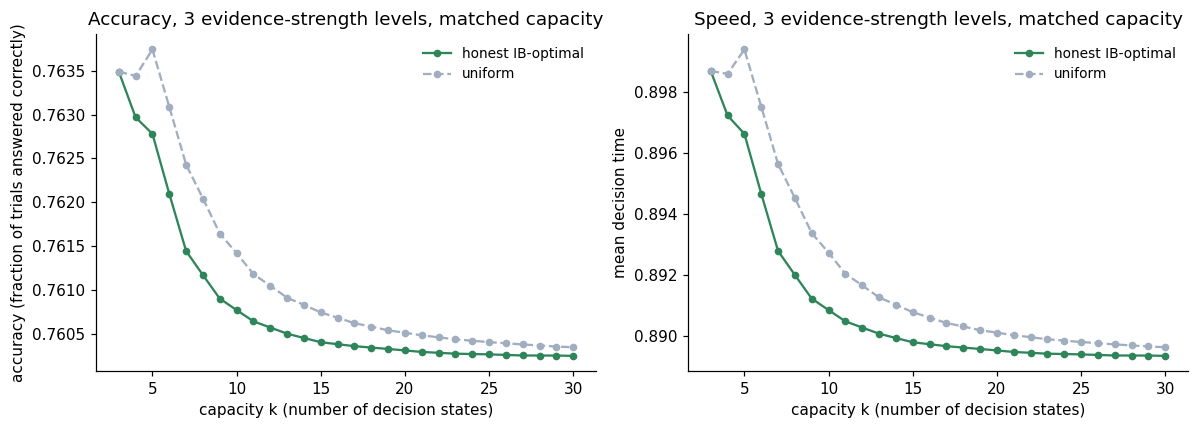

mean(honest - uniform) accuracy: -0.00037  (std 0.00029)
honest >= uniform in 1/28 cases


In [12]:
rows_snr = [ib_optimal_chain_snr_range_fixed_start(k0, k, branches_sym, s, a, z_frac) for k in k_list]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(k_list, [r["stats_opt"]["accuracy"] for r in rows_snr], "o-", ms=4,
        color="#2f855a", label="honest IB-optimal")
ax.plot(k_list, [r["stats_unif"]["accuracy"] for r in rows_snr], "o--", ms=4,
        color="#a0aec0", label="uniform")
ax.set_xlabel("capacity k (number of decision states)")
ax.set_ylabel("accuracy (fraction of trials answered correctly)")
ax.set_title("Accuracy, 3 evidence-strength levels, matched capacity")
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.plot(k_list, [r["stats_opt"]["expected_time"] for r in rows_snr], "o-", ms=4,
        color="#2f855a", label="honest IB-optimal")
ax.plot(k_list, [r["stats_unif"]["expected_time"] for r in rows_snr], "o--", ms=4,
        color="#a0aec0", label="uniform")
ax.set_xlabel("capacity k (number of decision states)")
ax.set_ylabel("mean decision time")
ax.set_title("Speed, 3 evidence-strength levels, matched capacity")
ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

diff_snr = np.array([r["stats_opt"]["accuracy"] - r["stats_unif"]["accuracy"] for r in rows_snr])
print(f"mean(honest - uniform) accuracy: {diff_snr.mean():+.5f}  (std {diff_snr.std():.5f})")
print(f"honest >= uniform in {(diff_snr >= -1e-9).sum()}/{len(diff_snr)} cases")


The finding from §3 replicates: it isn't specific to a single, known
evidence strength. Whether the uncertainty is about which side is correct,
how strong the evidence will be, or both together, spending the capacity
budget on maximizing `I(Y;R)` (bits of information about the answer) is not
a reliable way to get more answers right than simply spacing the decision
states out evenly.

### Does correctly accounting for the uncertainty about strength help, compared to guessing a single "typical" strength?

There's a narrower, more practical question this section can also answer.
Suppose the encoder-builder doesn't go to the trouble of modeling the full
range of evidence strengths, and instead just designs the encoder as if
every trial had one "typical" strength — say, the prior-weighted average.
That's a strictly simpler design, and it throws away real information (that
some trials are easier or harder than others). Does properly modeling the
*range* of strengths, rather than just its average, produce a placement
that's genuinely better in accuracy, even though (per above) it's still not
better than uniform spacing?


In [13]:
def naive_point_estimate_stats(k, v_levels, v_priors, pi, branches_true):
    """Build a placement as if every trial had the single average evidence
    strength (ignoring the spread), then score it honestly against the
    TRUE range of strengths -- the placement doesn't get to see the range,
    but reality still has one."""
    v_mean = float(np.sum(np.asarray(v_levels) * np.asarray(v_priors)))
    branches_point = snr_branches([v_mean], [1.0], pi)
    fr_point = mixture_fine_reference_multi(k0, branches_point, s, a, z_frac)
    b_p, _, _, z0p = optimal_partition_fixed_start(fr_point["w"], fr_point["q"], k, fr_point["z0_index"])
    xn_p = np.array([0.0] + list(group_centroids(fr_point["x"], fr_point["w"], b_p)) + [a])
    return mixture_chain_stats_multi(xn_p, branches_true, s, z0p), v_mean


print(f"{'spread':>28}  {'k':>3}  {'honest':>10}  {'naive point-est.':>17}  {'uniform':>10}  "
      f"{'honest - naive':>15}")
for label, v_levels_test, v_priors_test in [
    ("narrow: 0.3 / 0.6 / 0.9", [0.3, 0.6, 0.9], [0.25, 0.5, 0.25]),
    ("wide: 0.15 / 0.6 / 1.5", [0.15, 0.6, 1.5], [1 / 3, 1 / 3, 1 / 3]),
]:
    branches_test = snr_branches(v_levels_test, v_priors_test, pi=0.5)
    for k in [5, 10, 20]:
        r = ib_optimal_chain_snr_range_fixed_start(k0, k, branches_test, s, a, z_frac)
        naive_stats, v_mean = naive_point_estimate_stats(k, v_levels_test, v_priors_test, 0.5, branches_test)
        gap = r["stats_opt"]["accuracy"] - naive_stats["accuracy"]
        print(f"{label:>28}  {k:3d}  {r['stats_opt']['accuracy']:10.6f}  "
              f"{naive_stats['accuracy']:17.6f}  {r['stats_unif']['accuracy']:10.6f}  {gap:+15.6f}")


                      spread    k      honest   naive point-est.     uniform   honest - naive
     narrow: 0.3 / 0.6 / 0.9    5    0.762780           0.762774    0.763744        +0.000006
     narrow: 0.3 / 0.6 / 0.9   10    0.760768           0.760768    0.761418        +0.000001


     narrow: 0.3 / 0.6 / 0.9   20    0.760307           0.760304    0.760509        +0.000003
      wide: 0.15 / 0.6 / 1.5    5    0.769357           0.769336    0.770806        +0.000022
      wide: 0.15 / 0.6 / 1.5   10    0.766114           0.766060    0.766974        +0.000054


      wide: 0.15 / 0.6 / 1.5   20    0.765351           0.765328    0.765618        +0.000023


Correctly modeling the range of evidence strengths does help, consistently,
relative to pretending every trial is "typical" — but only by a very small
amount, and that amount grows with how spread out the strengths are (larger
for the wide 0.15/0.6/1.5 case than the narrow 0.3/0.6/0.9 one). Compare
the size of that gap to the honest-vs-uniform gap from earlier in this
section: modeling the range properly instead of naively is a small, second-
order refinement, while the cost of not knowing the answer at all (§4) and
the (tiny but consistent) cost of maximizing `I(Y;R)` instead of spacing
states evenly (§3, and again here) are both larger effects. The ranking
that matters most for this task's regime, in order of size: **knowing the
answer (§4) far outweighs everything else; not knowing the range of
strengths costs almost nothing as long as the average is used; and
"information-optimal" placement is a slight net negative relative to
uniform spacing, regardless of how much or how little is known about the
task.**


In [14]:
# validation: exact fundamental-matrix result vs. Gillespie (random-sampling) simulation,
# for the 3-magnitude-level honest placement -- same style of check as every other
# exact/simulated pair in this notebook series
k_val = 10
r_snr_val = ib_optimal_chain_snr_range_fixed_start(k0, k_val, branches_sym, s, a, z_frac)

for label, key_nodes, key_start in [("honest IB-optimal", "x_nodes_opt", "z0_group_opt"),
                                     ("uniform", "x_nodes_unif", "z0_group_unif")]:
    stats = r_snr_val["stats_opt"] if label == "honest IB-optimal" else r_snr_val["stats_unif"]
    rt_sim, correct_sim = mixture_simulate_multi(r_snr_val[key_nodes], branches_sym, s, r_snr_val[key_start],
                                                  n_trials=300_000, n_max=2000, seed=13)
    print(f"{label:18s} k={k_val}  exact: acc={stats['accuracy']:.4f} Et={stats['expected_time']:.4f}"
          f"   |   simulated: acc={np.nanmean(correct_sim):.4f} Et={np.nanmean(rt_sim):.4f}")


honest IB-optimal  k=10  exact: acc=0.7608 Et=0.8909   |   simulated: acc=0.7608 Et=0.8914


uniform            k=10  exact: acc=0.7614 Et=0.8927   |   simulated: acc=0.7625 Et=0.8945


## 10. Where this leaves us

**What's established here, exactly and validated:**
- The honest (prior-only) absorbing-bound IB placement has the same
  closed-form / exact structure as the oracle case — a prior-aware
  relevance sigmoid, an exact mixture occupancy, and the identical DP for
  the optimal partition — with no new machinery needed beyond the two
  changed inputs.
- At a symmetric prior, the resulting placement is provably and (here)
  numerically confirmed symmetric about the start point, unlike the
  known-drift notebook's placement, which was measurably biased toward the
  correct side.
- **A measurement artifact in the honest-vs-uniform comparison is fixed**
  (§3): forcing `z0` to be its own dedicated decision state in both
  placements removes an approximation that was adding noise (and, for
  asymmetric priors, real bias) to the comparison, using an exact,
  globally-optimal extension of the same dynamic program rather than a
  workaround.
- **The central, corrective finding, now sharper than before the fix, and
  confirmed to generalize beyond a single known evidence strength:** honest
  IB-optimal placement is not just "no better than" uniform spacing in
  actual decision accuracy — it is slightly and consistently *worse*,
  across essentially every capacity, every prior asymmetry, and (§9) every
  evidence-strength distribution tested, even though it still provably
  carries more `I(Y;R)` (bits of information about the answer) and still
  visibly concentrates states where the process spends the most time. Most
  of the known-drift notebook's clean "9/9 wins" advantage was the
  oracle's access to the answer, not a general property of information-
  optimal encoding.
- The cost of that knowledge is directly quantifiable (§4): comparing each
  placement's own natural starting rung (deliberately *not* the §3 fix,
  which would suppress exactly the mechanism being measured — confirmed
  directly by trying it anyway), the oracle beats both honest and uniform
  by a consistent few percentage points of accuracy, at every directly
  comparable capacity.
- Asymmetric priors do enter the encoder correctly (`qbar`, the marginal
  probability the answer is "upper," tracks `pi` exactly, a forced, checked
  consequence), but §6's second finding was that the naive picture of
  *where* that shows up is wrong: rung positions barely move even out to
  `pi=0.8` for this task's `v0`/`a`, because the relevance-driven and
  occupancy-driven pulls on the DP's placement largely cancel over that
  range.
- **A range of unknown evidence strengths, not just an unknown side, is now
  handled exactly** (§9): a complication that looked like it would force
  the representation to track elapsed time, not just position, turns out
  not to, because "occupancy" was already a time-marginalized quantity
  throughout this notebook series. Properly modeling the range of
  strengths (rather than just their average) gives a small, real,
  consistent accuracy edge over a naive "assume the average" encoder — but
  that edge is much smaller than either the honest-vs-uniform gap or the
  cost of not knowing the answer, so of the three kinds of uncertainty
  studied across this notebook (which side, how strong, and how much
  capacity), *which side* dominates the others by a wide margin.

**What's not yet done:**
- Everything flagged in the original plan for this notebook has now been
  built and checked. The natural next steps are less about this
  notebook's own machinery and more about connecting it back to real data:
  fitting a standard drift-diffusion model to synthetic choice/reaction-
  time data generated from the honest placement (across a range of
  capacities `k`), to see which drift-diffusion-model parameter absorbs a
  capacity manipulation now that the encoder generating the data is
  actually the right one to use — the question the original plan (this
  project's `Overview.md`) posed at the outset, now answerable with a
  properly-derived, validated encoder rather than a placeholder uniform
  one or an unrealistic oracle.
